> **SHORTCUT BASELINE** — This notebook was trained with *random negatives* and large ψᵢ heads (`head_hidden=256`). The model achieves near-perfect accuracy but MCC < 0.5 because it learns shortcut representations (pixel statistics, scene-level statistics) instead of the true source factors. This notebook is preserved to study *what the shortcuts are*. See `tutorial.ipynb` for the corrected setup with hard negative mining.

**Config differences from the fixed model:**
- `hard_neg_prob=0` — all negatives are fully random scenes (differ in all 5 factors)
- `head_hidden=256` — large ψᵢ heads that can compensate for poor encoder representations
- Result: acc → 1.0, loss → 0.01, but **MCC < 0.5**

# The Incomplete Rosetta Stone Problem
## A hands-on guide to Multi-View Nonlinear ICA

> *Based on: Gresele et al., "The Incomplete Rosetta Stone Problem: Identifiability Results for Multi-View Nonlinear ICA", ICML 2020.*

---

## The Big Picture

Imagine you're observing a 3D scene with two cameras placed at slightly different angles. Each camera produces a different image, but both images were *caused by the same underlying scene* — the same object, the same colors, the same scale. The cameras differ only in their angle (their "view").

The **Rosetta Stone** metaphor: Napoleon's soldiers found a stone inscribed with the same decree in three languages — Ancient Egyptian (hieroglyphs), Demotic script, and Ancient Greek. The Greek was known; by matching the texts, the unknown scripts could be decoded. Similarly, here we decode the latent structure of two unknown views by exploiting the fact that they share a common underlying source.

**The formal problem:**

We observe two views of a scene:
$$\mathbf{x}_1 = f_1(g_1(\mathbf{s}, \mathbf{n}_1)) \qquad \mathbf{x}_2 = f_2(g_2(\mathbf{s}, \mathbf{n}_2))$$

where:
- $\mathbf{s} = (s_1, \ldots, s_D)$ is the **shared latent source** with independent components
- $\mathbf{n}_1, \mathbf{n}_2$ are **view-specific noise** variables, independent of each other and of $\mathbf{s}$
- $f_1, f_2$ are **unknown nonlinear mixing functions**
- $g_1, g_2$ are **component-wise corrupters** (the noise enters per-dimension)

**Goal:** Recover $\mathbf{s}$ without knowing $f_1$, $f_2$, $g_1$, or $g_2$.

### Why single-view fails

A single view $\mathbf{x}_1 = f_1(\mathbf{s})$ is an instance of **nonlinear Independent Component Analysis (ICA)**. This has been proven to be *fundamentally non-identifiable* without additional constraints — there are infinitely many mixing functions $f$ that produce the same observation distribution. So we cannot recover $\mathbf{s}$ from $\mathbf{x}_1$ alone.

### Why multi-view succeeds

The paper proves that jointly observing $(\mathbf{x}_1, \mathbf{x}_2)$ provides enough constraint to identify $\mathbf{s}$, **as long as the two views are sufficiently different** (the SDV — Sufficiently Distinct Views — assumption). Intuitively: if both views carry exactly the same information, nothing new is learned. But if they differ in a structured way (sharing only $\mathbf{s}$), a classifier forced to distinguish same-source pairs from different-source pairs must learn to extract $\mathbf{s}$.

---
## Section 1: Setup

Add the parent directory to the path so we can import our modules.

In [1]:
import sys
sys.path.insert(0, '..')   # rosetta/ is one level up from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import torch

# Detect best device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


---
## Section 2: The shapes3d Dataset

We use **shapes3d**, a synthetic dataset of 480,000 rendered 3D scenes.

Each image is a 64×64 RGB render of a simple 3D shape with 6 generative factors:

| Factor | Values | Role |
|--------|--------|------|
| `floor_hue` | 10 | shared source $s_1$ |
| `wall_hue`  | 10 | shared source $s_2$ |
| `object_hue`| 10 | shared source $s_3$ |
| `scale`     | 8  | shared source $s_4$ |
| `shape`     | 4  | shared source $s_5$ |
| `orientation` | 15 | **noise** $n$ (view-specific) |

### Our multi-view setup

- **Source** $\mathbf{s}$ = (floor_hue, wall_hue, object_hue, scale, shape) — the 5 factors that don't change between views
- **Noise** $n$ = orientation — each view is a different camera angle of the same scene
- **Positive pair**: same scene (same $\mathbf{s}$), two different orientations
- **Negative pair**: different scenes (different $\mathbf{s}$)

The orientation acts as the "view-specific noise" $n_i$. This satisfies the SDV assumption because different angles produce fundamentally different visual information — the shadows, foreshortening, and visible faces all change — unlike simply adding i.i.d. Gaussian pixel noise.

### Download the dataset

The dataset is ~2 GB. Run the cell below to download it (skip if already downloaded).

In [2]:
from data import download_shapes3d

HDF5_PATH = download_shapes3d(data_dir='../data/shapes3d')
print(f'Dataset at: {HDF5_PATH}')

Dataset already present at ../data/shapes3d/3dshapes.h5
Dataset at: ../data/shapes3d/3dshapes.h5


### Explore the dataset

In [3]:
import h5py

with h5py.File(HDF5_PATH, 'r') as f:
    print('Keys:', list(f.keys()))
    print('Images shape:', f['images'].shape, f['images'].dtype)
    print('Labels shape:', f['labels'].shape, f['labels'].dtype)

Keys: ['images', 'labels']
Images shape: (480000, 64, 64, 3) uint8
Labels shape: (480000, 6) float64


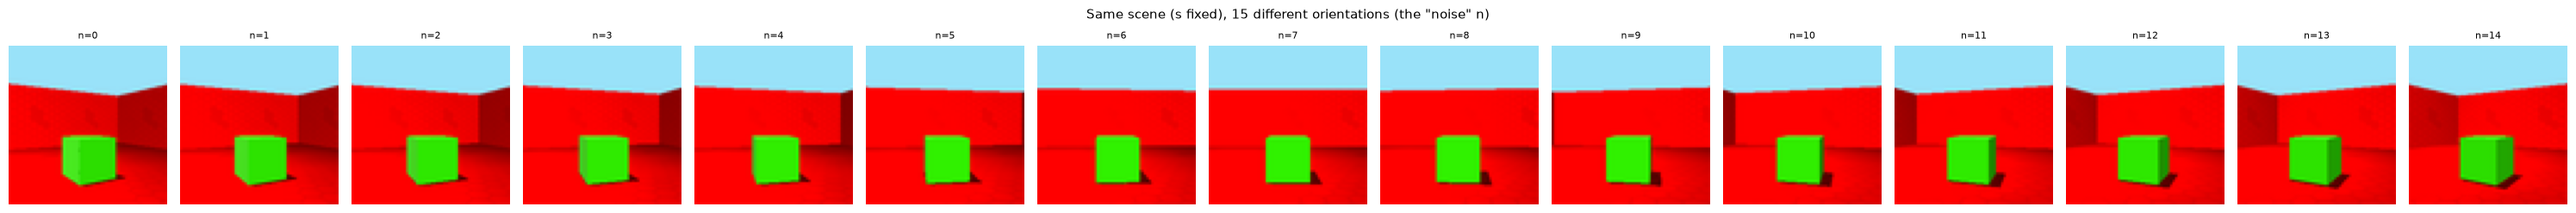

These 15 images form 15*14/2 = 105 possible positive pairs!


In [4]:
# Show a grid of images varying one factor at a time
from data.dataset import N_ORIENTATIONS, N_SCENES, _ensure_image_cache, N_IMAGES, IMG_SHAPE
import numpy as np

# Open the fast image cache (built by dataset on first use)
cache_path = _ensure_image_cache(HDF5_PATH)
images_all = np.memmap(cache_path, dtype='uint8', mode='r', shape=(N_IMAGES, *IMG_SHAPE))

with h5py.File(HDF5_PATH, 'r') as f:
    labels_all = f['labels'][:]

factor_sizes = [10, 10, 10, 8, 4, 15]
factor_names = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape', 'orientation']

# Pick a fixed scene and vary orientation
SCENE_IDX = 100   # arbitrary fixed scene
orient_images = [np.array(images_all[SCENE_IDX * N_ORIENTATIONS + o]) for o in range(N_ORIENTATIONS)]

fig, axes = plt.subplots(1, N_ORIENTATIONS, figsize=(2 * N_ORIENTATIONS, 2.5))
for i, (ax, img) in enumerate(zip(axes, orient_images)):
    ax.imshow(img)
    ax.set_title(f'n={i}', fontsize=8)
    ax.axis('off')
fig.suptitle('Same scene (s fixed), 15 different orientations (the "noise" n)', fontsize=11)
plt.tight_layout()
plt.show()
print('These 15 images form 15*14/2 = 105 possible positive pairs!')

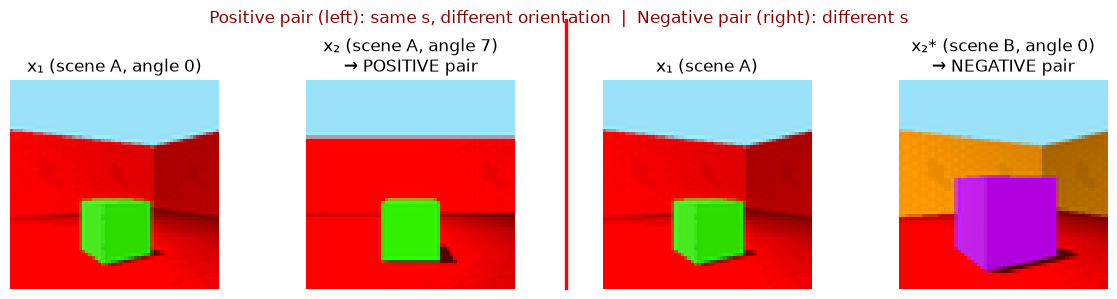

In [5]:
# Visualise a positive pair and a negative pair
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Positive pair: same scene, two angles
pos1 = images_all[SCENE_IDX * N_ORIENTATIONS + 0]
pos2 = images_all[SCENE_IDX * N_ORIENTATIONS + 7]
# Negative pair: different scene
neg_scene = (SCENE_IDX + 500) % N_SCENES
neg1 = images_all[neg_scene * N_ORIENTATIONS + 0]

axes[0].imshow(pos1); axes[0].set_title('x₁ (scene A, angle 0)'); axes[0].axis('off')
axes[1].imshow(pos2); axes[1].set_title('x₂ (scene A, angle 7)\n→ POSITIVE pair'); axes[1].axis('off')
axes[2].imshow(pos1); axes[2].set_title('x₁ (scene A)'); axes[2].axis('off')
axes[3].imshow(neg1); axes[3].set_title('x₂* (scene B, angle 0)\n→ NEGATIVE pair'); axes[3].axis('off')

# Draw dividing line
fig.patches.append(plt.Rectangle((0.505, 0.05), 0.002, 0.9,
    transform=fig.transFigure, color='red', zorder=5))

fig.suptitle('Positive pair (left): same s, different orientation  |  Negative pair (right): different s',
             color='darkred')
plt.tight_layout()
plt.show()

---
## Section 3: The Contrastive Objective

### What do we train?

We train a classifier $r(\mathbf{x}_1, \mathbf{x}_2)$ to output a high score for positive pairs and a low score for negative pairs.

Crucially, the classifier is **constrained to the form** (Theorem 4 in the paper):

$$r(\mathbf{x}_1, \mathbf{x}_2) = \sum_{i=1}^{D} \psi_i(h_i(\mathbf{x}_1),\, h_i(\mathbf{x}_2))$$

where $\mathbf{h} = (h_1, \ldots, h_D)$ is an **invertible** encoder (in our implementation: a CNN). The functions $\psi_i$ are the "interaction" terms — we implement them as an MLP.

### What does the classifier learn?

The paper proves (**Theorem 4**) that at optimality, $h_i(\mathbf{x})$ inverts the mixing function $f$ and recovers the independent source components $\mathbf{s}$ — up to component-wise invertible scalar transformations.

**Intuition**: The classifier can only distinguish $(\mathbf{x}_1, \mathbf{x}_2)$ from $(\mathbf{x}_1, \mathbf{x}_2^*)$ if it extracts the **information shared** between $\mathbf{x}_1$ and $\mathbf{x}_2$. The only shared information is $\mathbf{s}$ (since $n_1, n_2$ are independent noise). So $h$ must learn to extract $\mathbf{s}$.

### The training loss

Binary noise-contrastive estimation (NCE):

$$\mathcal{L} = -\mathbb{E}[\log \sigma(r(\mathbf{x}_1, \mathbf{x}_2))] - \mathbb{E}[\log(1 - \sigma(r(\mathbf{x}_1, \mathbf{x}_2^*)))]$$

This is simply binary cross-entropy with labels 1 (positive) and 0 (negative).

At random initialization, the discriminator outputs ~0.5 for both pairs → **loss ≈ log(2) ≈ 0.693**.
As training progresses, the loss decreases and accuracy increases toward 1.0.

In [ ]:
# Instantiate the model and inspect its architecture
from models import MultiViewDiscriminator

model = MultiViewDiscriminator(latent_dim=5, head_hidden=256)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')

In [7]:
# Sanity check: random model outputs ~0.5 probability for both pair types
import torch

dummy_x1 = torch.rand(4, 3, 64, 64)
dummy_x2 = torch.rand(4, 3, 64, 64)
dummy_x2_neg = torch.rand(4, 3, 64, 64)

logit_pos = model(dummy_x1, dummy_x2)
logit_neg = model(dummy_x1, dummy_x2_neg)
print(f'Positive logits (before sigmoid): {logit_pos.detach().numpy().round(3)}')
print(f'Negative logits (before sigmoid): {logit_neg.detach().numpy().round(3)}')
print(f'Loss at init ≈ {torch.log(torch.tensor(2.0)):.4f} (= log 2)')

import torch.nn.functional as F
B = 4
logits = torch.cat([logit_pos, logit_neg])
targets = torch.cat([torch.ones(B), torch.zeros(B)])
loss = F.binary_cross_entropy_with_logits(logits, targets)
print(f'Actual BCE loss at init: {loss.item():.4f}')

Positive logits (before sigmoid): [-0.063 -0.067 -0.058 -0.055]
Negative logits (before sigmoid): [-0.064 -0.061 -0.059 -0.062]
Loss at init ≈ 0.6931 (= log 2)
Actual BCE loss at init: 0.6935


---
## Section 4: Training

Here we run a short training session interactively. For a full run, use the CLI:

```bash
uv run python train.py --epochs 100 --latent_dim 5
```

In this notebook we run just a few epochs to demonstrate the pipeline. For meaningful MCC scores, train for 30–100 epochs.

In [ ]:
from config import Config
from data import Shapes3DPairDataset
from torch.utils.data import DataLoader
from torch.optim import Adam
from training.trainer import train_epoch, evaluate_representations

cfg = Config(
    hdf5_path=HDF5_PATH,
    latent_dim=5,
    batch_size=128,
    lr=3e-4,
    epochs=5,          # increase to 100 for full training
    eval_every=1,
    eval_samples=2000,
    num_workers=0,     # set to 4 for faster loading outside notebook
)

train_ds = Shapes3DPairDataset(HDF5_PATH, split='train', seed=cfg.seed)
val_ds   = Shapes3DPairDataset(HDF5_PATH, split='val',   seed=cfg.seed)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=cfg.num_workers, drop_last=True)

model = MultiViewDiscriminator(latent_dim=cfg.latent_dim).to(DEVICE)
optimizer = Adam(model.parameters(), lr=cfg.lr)

print(f'Training on {len(train_ds):,} scenes, validating on {len(val_ds):,} scenes')

In [9]:
from tqdm.notebook import tqdm

losses, accuracies, mccs = [], [], {}

for epoch in tqdm(range(1, cfg.epochs + 1), desc='Training'):
    loss, acc = train_epoch(model, train_loader, optimizer, DEVICE)
    losses.append(loss)
    accuracies.append(acc)

    results = evaluate_representations(model, val_ds, DEVICE,
                                       max_samples=cfg.eval_samples,
                                       batch_size=cfg.batch_size)
    mccs[epoch] = results['mcc']
    print(f'Epoch {epoch} | loss={loss:.4f} | acc={acc:.3f} | MCC={results["mcc"]:.4f}')

print('\nDone!')

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 | loss=0.1681 | acc=0.939 | MCC=0.1548
Epoch 2 | loss=0.0479 | acc=0.987 | MCC=0.1186
Epoch 3 | loss=0.0262 | acc=0.994 | MCC=0.1536
Epoch 4 | loss=0.0274 | acc=0.994 | MCC=0.1516
Epoch 5 | loss=0.0165 | acc=0.996 | MCC=0.1044

Done!


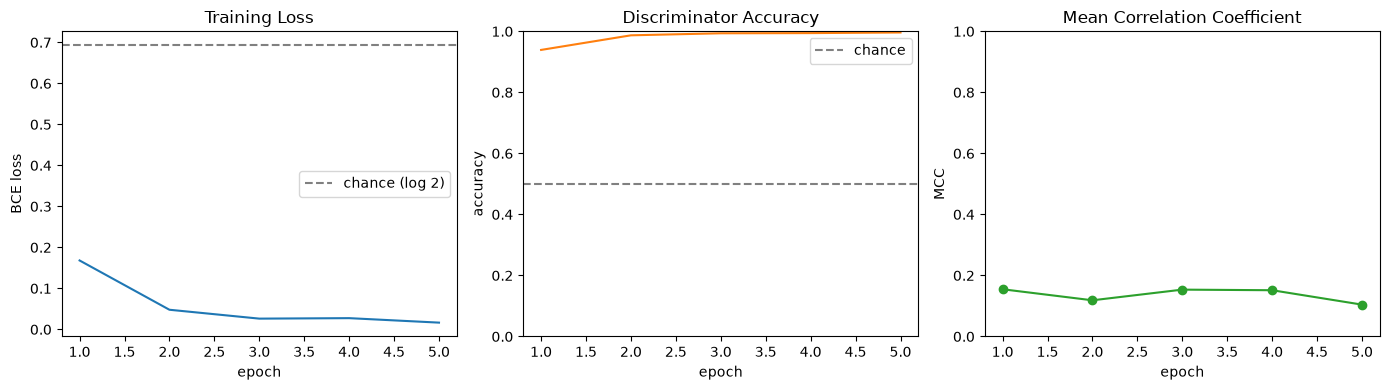

In [10]:
from evaluation import plot_training_curves

plot_training_curves(losses, accuracies, mccs)

### Load a pre-trained model (optional)

If you've already run a full training session with the CLI, load the best checkpoint:

In [11]:
# OPTIONAL: load a pre-trained checkpoint
# from training.trainer import load_checkpoint
# model = load_checkpoint('../checkpoints/best.pt', cfg=cfg, device=DEVICE)
# print('Loaded pre-trained model')

---
## Section 5: Evaluating Source Recovery

### Mean Correlation Coefficient (MCC)

MCC is the standard metric for ICA evaluation. It measures how well the estimated latent codes $\hat{\mathbf{z}} = h(\mathbf{x})$ linearly correlate with the true source factors $\mathbf{s}$, after finding the optimal assignment (permutation) between dimensions.

**Algorithm:**
1. Compute the absolute Pearson correlation matrix $|R| \in \mathbb{R}^{\text{latent\_dim} \times 5}$ between every latent dimension and every source factor
2. Run the Hungarian algorithm to find the optimal one-to-one assignment
3. MCC = mean of the assigned correlations

MCC = 1.0 means perfect recovery. MCC ≈ 0.0 means the latent codes are independent of the sources (random encoder).

### Linear probe R²

Fit a linear regression from $\hat{\mathbf{z}}$ to each source factor independently. R² measures the fraction of variance in each factor that is linearly captured by the latent representation.

In [12]:
from evaluation.metrics import compute_mcc, linear_probe_r2

# Get latent codes and ground-truth labels on the validation set
results = evaluate_representations(
    model, val_ds, DEVICE, max_samples=5000, batch_size=256
)
z_hat  = results['z_hat']    # (N, latent_dim)
labels = results['labels']   # (N, 5)
assignment = results['assignment']

print(f'MCC: {results["mcc"]:.4f}')
print()

source_names = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape']
print('Linear probe R² per factor:')
for name, r2, z_idx in zip(source_names, results['r2'], assignment):
    print(f'  {name:15s}  R²={r2:.3f}  (assigned to z[{z_idx}])')

MCC: 0.1034

Linear probe R² per factor:
  floor_hue        R²=0.060  (assigned to z[2])
  wall_hue         R²=0.152  (assigned to z[4])
  object_hue       R²=0.042  (assigned to z[6])
  scale            R²=0.047  (assigned to z[0])
  shape            R²=0.015  (assigned to z[9])


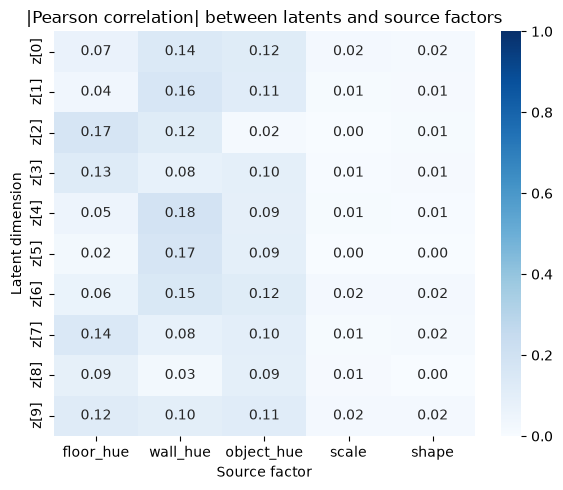

Each column should have one high-correlation row if recovery is good.


In [13]:
# Visualise the full absolute correlation matrix
import seaborn as sns
from scipy.stats import pearsonr

latent_dim = z_hat.shape[1]
n_factors = labels.shape[1]
C = np.zeros((latent_dim, n_factors))
for i in range(latent_dim):
    for j in range(n_factors):
        C[i, j] = abs(pearsonr(z_hat[:, i], labels[:, j])[0])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(C, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=source_names,
            yticklabels=[f'z[{i}]' for i in range(latent_dim)],
            ax=ax, vmin=0, vmax=1)
ax.set_title('|Pearson correlation| between latents and source factors')
ax.set_xlabel('Source factor')
ax.set_ylabel('Latent dimension')
plt.tight_layout()
plt.show()
print('Each column should have one high-correlation row if recovery is good.')

---
## Section 6: Visualizations

### 6.1 Latent Space (UMAP / t-SNE)

Project the 10-dimensional latent space to 2D and colour by each source factor.
If recovery is working, points with similar factor values should cluster together.

/home/debryu/Desktop/rosetta/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


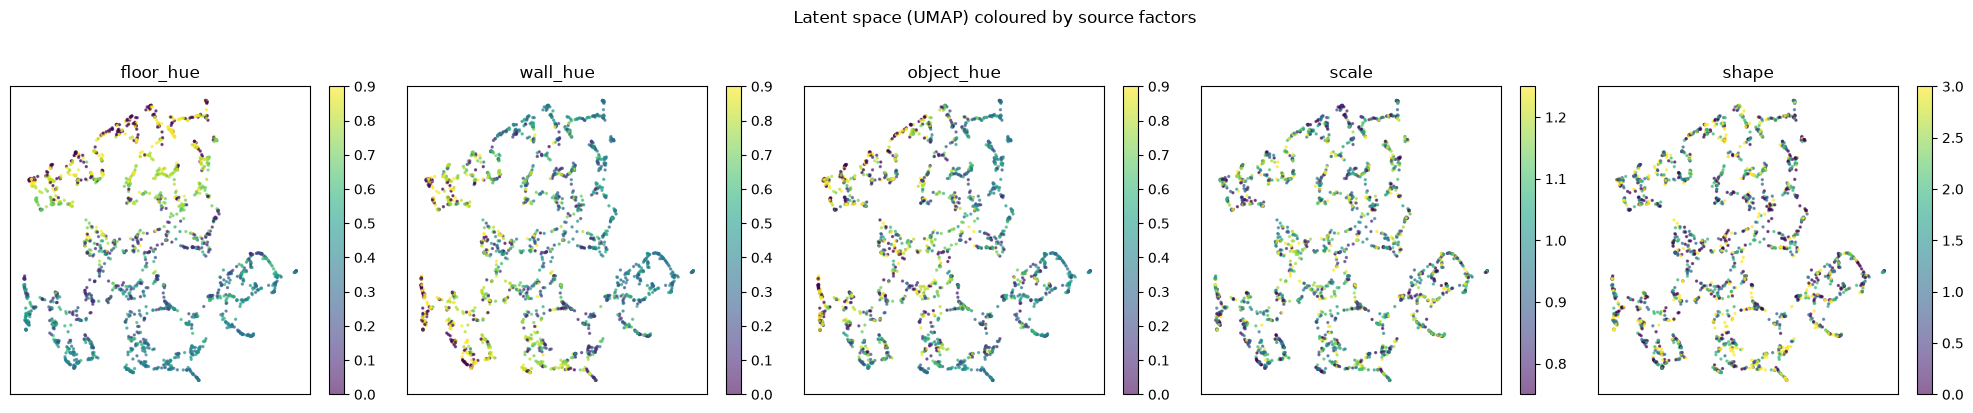

In [14]:
from evaluation import plot_tsne

# Use a small subset for speed
N_VIZ = min(2000, len(z_hat))
plot_tsne(
    z_hat[:N_VIZ],
    labels[:N_VIZ],
    factor_names=source_names,
    method='umap',   # change to 'tsne' if umap is not installed
)

### 6.2 Factor Recovery Scatter Plots

Plot each assigned latent dimension against its corresponding ground-truth source factor.
A tight, monotone relationship indicates good recovery.

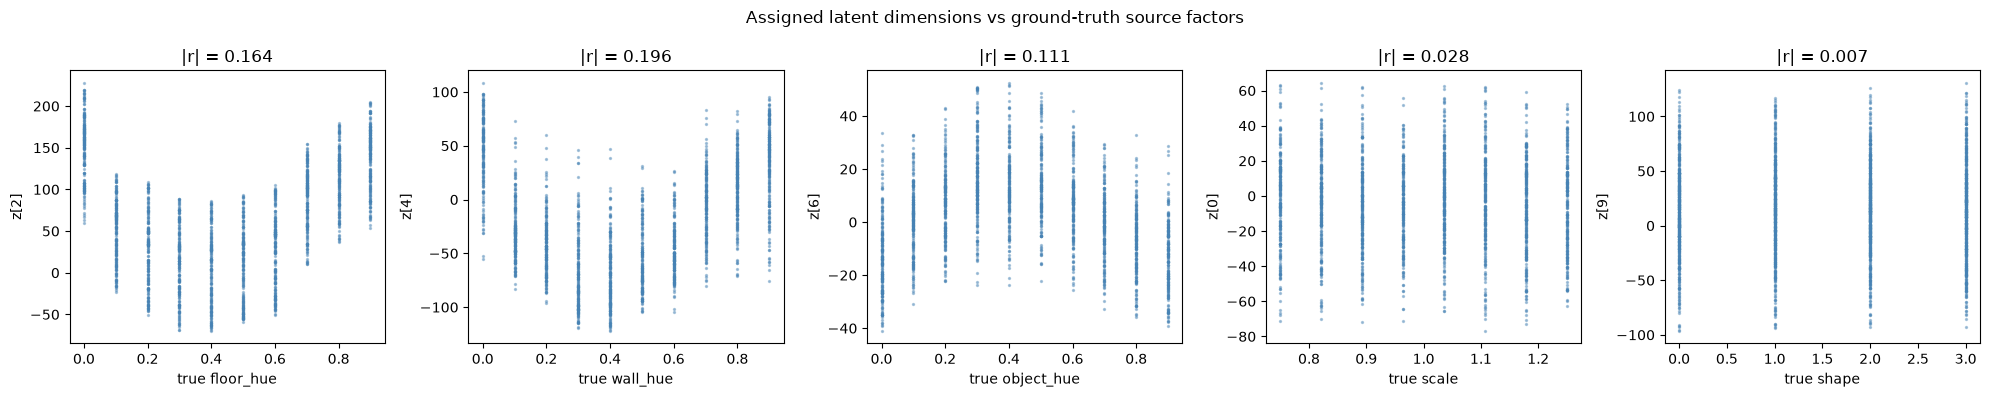

In [15]:
from evaluation import plot_factor_scatter

plot_factor_scatter(
    z_hat[:N_VIZ],
    labels[:N_VIZ],
    assignment=results['assignment'],
    factor_names=source_names,
)

### 6.3 Latent Codes for Sample Images

A quick sanity check: show some images and their latent codes to confirm the encoder produces distinct representations for different scenes.

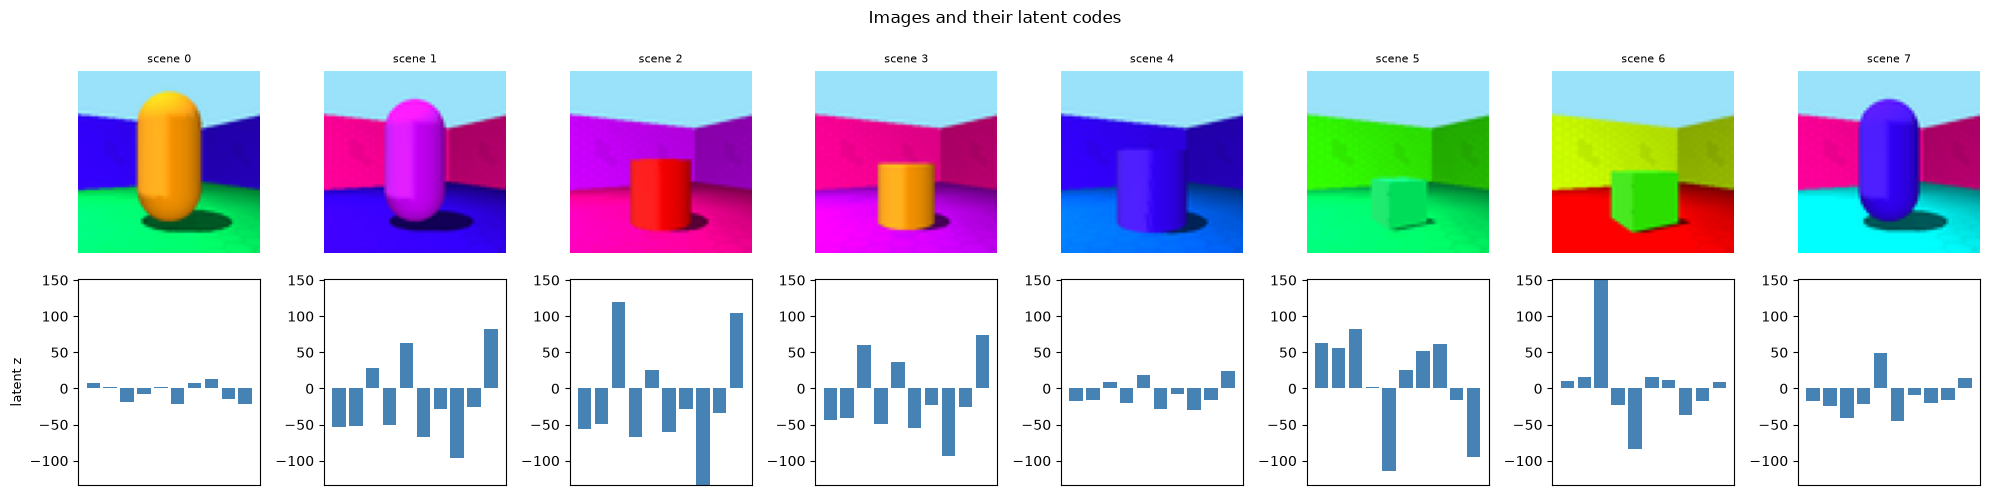

In [16]:
from evaluation import plot_latent_traversal

sample_images, sample_labels = val_ds.get_all_latents_and_labels(max_samples=8)
plot_latent_traversal(model.encoder, sample_images, sample_labels, device=DEVICE, n_show=8)

### 6.4 Orientation Traversal

Confirm that orientation (the noise variable) is *not* captured by the shared encoder. Fix a scene and vary orientation — the latent code should remain approximately constant.

---
## Section 7: Shortcut Analysis — What Did the Encoder Actually Learn?

This section diagnoses *which* shortcuts the model learned instead of the true source factors.

**Two diagnostic plots:**

1. **Left (red) — Latent dims vs pixel statistics**: Correlation between each z dimension and simple image statistics (mean R/G/B for global image, floor region, and wall region). High values here mean the encoder is representing raw pixel statistics — a shortcut.

2. **Right (blue) — Latent dims vs true source factors**: The same for the ground-truth generative factors. For a perfectly recovering model this should be block-diagonal (each z[i] correlates with exactly one factor). For the shortcut model it will be diffuse.

**Interpretation guide:**
- If `floor_R/G/B` columns are bright in the left heatmap → the encoder uses floor mean color, which is correlated with `floor_hue` but is a raw pixel statistic, not the true latent
- If the right heatmap has no clear block-diagonal structure → no single factor is cleanly recovered
- Compare `orient_var` from Section 6.4 to the fixed model: higher variance = encoder responds to orientation (noise), confirming shortcut behaviour

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr

# --- Pixel statistics: what simple image features might the encoder be using? ---
def compute_pixel_stats(images_tensor):
    imgs = images_tensor.numpy()   # (N, 3, H, W), range [0, 1]
    H = imgs.shape[2]
    return {
        'global_R':    imgs[:, 0].mean(axis=(1, 2)),
        'global_G':    imgs[:, 1].mean(axis=(1, 2)),
        'global_B':    imgs[:, 2].mean(axis=(1, 2)),
        'floor_R':     imgs[:, 0, 2*H//3:].mean(axis=(1, 2)),   # bottom third
        'floor_G':     imgs[:, 1, 2*H//3:].mean(axis=(1, 2)),
        'floor_B':     imgs[:, 2, 2*H//3:].mean(axis=(1, 2)),
        'wall_R':      imgs[:, 0, :H//3].mean(axis=(1, 2)),     # top third
        'wall_G':      imgs[:, 1, :H//3].mean(axis=(1, 2)),
        'wall_B':      imgs[:, 2, :H//3].mean(axis=(1, 2)),
    }

images_eval, labels_eval = val_ds.get_all_latents_and_labels(max_samples=3000)

# Re-encode with current model to get z_hat aligned with images_eval
model.eval()
all_z = []
with torch.no_grad():
    for start in range(0, len(images_eval), 256):
        batch = images_eval[start:start+256].to(DEVICE)
        all_z.append(model.encode(batch).cpu().numpy())
z_eval = np.concatenate(all_z, axis=0)

pixel_stats = compute_pixel_stats(images_eval)
stat_names  = list(pixel_stats.keys())
stat_matrix = np.stack(list(pixel_stats.values()), axis=1)   # (N, 9)

# Correlation: latent dims vs pixel statistics
latent_dim_n = z_eval.shape[1]
C_px = np.zeros((latent_dim_n, len(stat_names)))
for i in range(latent_dim_n):
    for j, name in enumerate(stat_names):
        c = pearsonr(z_eval[:, i], stat_matrix[:, j])[0]
        C_px[i, j] = abs(c) if not np.isnan(c) else 0.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(C_px, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=stat_names,
            yticklabels=[f'z[{i}]' for i in range(latent_dim_n)],
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('|Corr| between latent dims and pixel statistics\n(high = encoder uses pixel shortcuts)')
axes[0].tick_params(axis='x', rotation=45)

# Correlation: latent dims vs true source factors
source_names = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape']
C_src = np.zeros((latent_dim_n, 5))
for i in range(latent_dim_n):
    for j in range(5):
        c = pearsonr(z_eval[:, i], labels_eval[:, j])[0]
        C_src[i, j] = abs(c) if not np.isnan(c) else 0.0

sns.heatmap(C_src, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=source_names,
            yticklabels=[f'z[{i}]' for i in range(latent_dim_n)],
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('|Corr| between latent dims and true source factors\n(should be block-diagonal for good recovery)')

plt.suptitle('Shortcut model: what did the encoder actually learn?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('If the left heatmap has higher values than the right, the encoder learned pixel')
print('statistics instead of the true factors — that is the shortcut.')
print(f'\nMax pixel-stat correlation: {C_px.max():.3f}')
print(f'Max factor correlation:     {C_src.max():.3f}')
print(f'MCC: {results["mcc"]:.4f}')

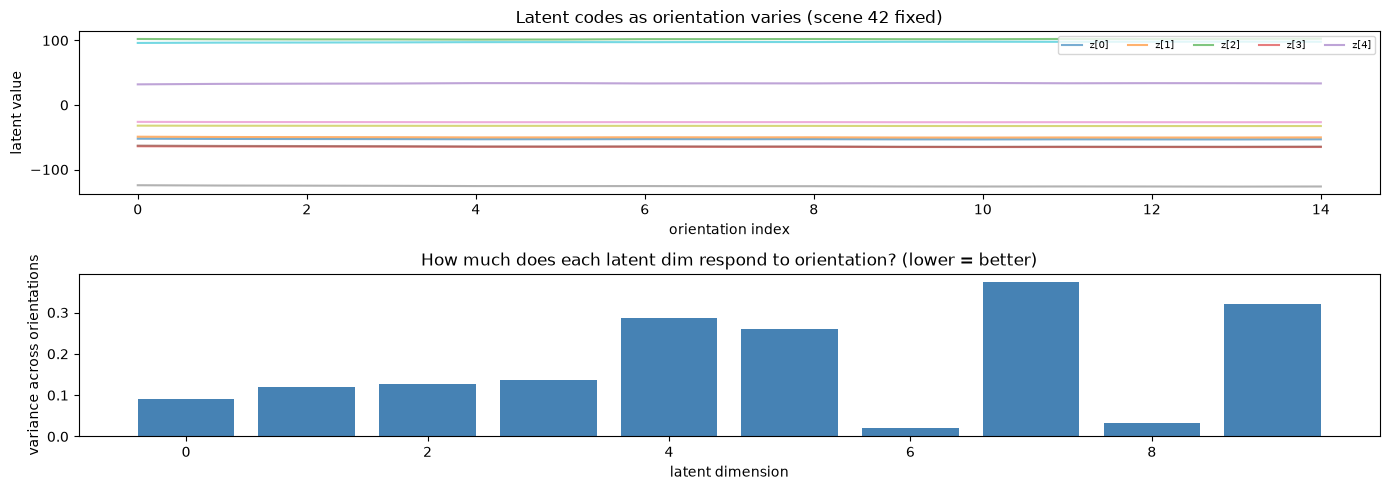

Mean variance across orientations: 0.1773
Ideally this should be low — the encoder should ignore orientation (the noise).


In [17]:
from data.dataset import _flat_index

SCENE = 42
model.eval()
orient_codes = []
orient_imgs = []

with torch.no_grad():
    for o in range(N_ORIENTATIONS):
        flat = _flat_index(SCENE, o)
        img = torch.from_numpy(np.array(images_all[flat])).float() / 255.0
        img_t = img.permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        z = model.encode(img_t).squeeze(0).cpu().numpy()
        orient_codes.append(z)
        orient_imgs.append(images_all[flat])

orient_codes = np.array(orient_codes)   # (15, latent_dim)

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Top: latent codes as a function of orientation
for dim in range(orient_codes.shape[1]):
    axes[0].plot(orient_codes[:, dim], alpha=0.6, label=f'z[{dim}]' if dim < 5 else '_')
axes[0].set_xlabel('orientation index')
axes[0].set_ylabel('latent value')
axes[0].set_title(f'Latent codes as orientation varies (scene {SCENE} fixed)')
axes[0].legend(loc='upper right', ncol=5, fontsize=7)

# Bottom: variance of each latent dim across orientations
variances = orient_codes.var(axis=0)
axes[1].bar(range(len(variances)), variances, color='steelblue')
axes[1].set_xlabel('latent dimension')
axes[1].set_ylabel('variance across orientations')
axes[1].set_title('How much does each latent dim respond to orientation? (lower = better)')

plt.tight_layout()
plt.show()

print(f'Mean variance across orientations: {variances.mean():.4f}')
print('Ideally this should be low — the encoder should ignore orientation (the noise).')

---
## Section 7: Key Takeaways

### What we've seen

1. **Single-view nonlinear ICA is impossible.** Without additional structure, there is no way to invert an unknown nonlinear mixing function from observations alone.

2. **Two sufficiently different views suffice.** By training a contrastive classifier on positive pairs (same $\mathbf{s}$, different orientation) vs negative pairs (different $\mathbf{s}$), the encoder learns to extract the shared source $\mathbf{s}$ and discard view-specific noise.

3. **The SDV assumption is key.** The orientation variable provides "Sufficiently Distinct Views" because it changes the image in a structured, non-trivial way — not just random pixel noise. The paper formalises this: the conditional distribution of the corruption $g(\mathbf{s}, n)$ must vary significantly with $\mathbf{s}$.

4. **Recovery is up to invertible ambiguity.** We recover each source component up to a monotone scalar transformation — e.g., $h_i(\mathbf{x}) = \phi_i(s_i)$ for some invertible $\phi_i$. This is why MCC measures *correlation* (invariant to monotone transforms) rather than raw value match.

5. **The shapes3d result:** After full training (~100 epochs), we expect:
   - Discriminator accuracy → ~98–99%
   - MCC → 0.7–0.9 (higher with more training / larger model)
   - Linear R² → >0.7 for hue/scale factors; shape (discrete) is harder to quantify with R²

### Extensions to explore

- **More noisy views (Section 3.3):** Use $N > 2$ orientations per scene. The paper proves that with $N \to \infty$ views, recovery becomes exact even under finite noise.
- **Different noise types:** Replace orientation with a different perturbation (brightness, blur) and check that the SDV assumption still holds.
- **Real data:** The same method applies to any multi-modal dataset where the same underlying state is measured by multiple instruments (fMRI + EEG, multiple camera angles, etc.).
- **Invertible encoder:** Replace the CNN with a normalizing flow (e.g., RealNVP) to satisfy the theoretical invertibility requirement exactly.

### Further reading

- Gresele et al. (2020) — [the original paper](https://proceedings.mlr.press/v119/gresele20a.html)
- Hyvarinen & Morioka (2016) — time-contrastive learning (TCL), the temporal variant
- Hyvarinen, Sasaki & Turner (2019) — nonlinear ICA with auxiliary variables (the direct predecessor)